# **1. Perkenalan Dataset**

## Developer Burnout Prediction Dataset (7000 Samples)

**Sumber:** [Kaggle - Developer Burnout Prediction Dataset (7000 Samples)](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)

**Deskripsi:**  
Dataset ini berisi data fisiologis dan kebiasaan kerja dari para software developer yang digunakan untuk memprediksi tingkat burnout. Terdapat 7.000 sampel dengan 11 fitur numerik dan 1 target kategorikal.

**Informasi Fitur:**

| Fitur | Tipe | Deskripsi |
|---|---|---|
| `age` | Numerik | Usia developer (tahun) |
| `experience_years` | Numerik | Lama pengalaman kerja (tahun) |
| `daily_work_hours` | Numerik | Jam kerja per hari |
| `sleep_hours` | Numerik | Rata-rata jam tidur per malam |
| `caffeine_intake` | Numerik | Konsumsi kafein per hari (cangkir) |
| `bugs_per_day` | Numerik | Jumlah bug yang dikerjakan per hari |
| `commits_per_day` | Numerik | Jumlah commit per hari |
| `meetings_per_day` | Numerik | Jumlah meeting per hari |
| `screen_time` | Numerik | Waktu layar per hari (jam) |
| `exercise_hours` | Numerik | Jam olahraga per hari |
| `stress_level` | Numerik | Skor tingkat stres (0-100) |
| `burnout_level` | Kategorikal | **Target** — tingkat burnout: Low / Medium / High |

**Problem Type:** Multiclass Classification  
**Distribusi Target:**  
- Medium: ~49.8%  
- High: ~25.5%  
- Low: ~22.8%

# **2. Import Library**

Import semua library yang diperlukan untuk analisis data, visualisasi, dan preprocessing.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
TEST_SIZE = 0.2
OUTPUT_DIR = 'developer_burnout_preprocessing'
TARGET = 'burnout_level'

print('Library berhasil di load.')

Library berhasil di load.


# **3. Memuat Dataset**

Memuat dataset dari file CSV dan melakukan inspeksi awal terhadap struktur, tipe data, dan kualitas data.

In [2]:
df = pd.read_csv('../developer_burnout_raw/developer_burnout.csv')

print(f'Shape   : {df.shape}')
print(f'Kolom   : {df.columns.tolist()}')
df.head(10)

Shape   : (7000, 12)
Kolom   : ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.000,12.000,10.330,4.450,2.000,11.000,4.000,1.000,15.070,0.140,55.960,Medium
1,39.000,10.000,8.620,5.770,5.000,15.000,11.000,5.000,13.250,0.540,82.220,High
2,34.000,13.000,NaN,4.030,5.000,2.000,18.000,9.000,11.180,1.540,61.770,Medium
3,30.000,1.000,6.850,6.470,2.000,15.000,26.000,1.000,11.140,0.960,54.980,Medium
4,27.000,7.000,4.240,5.800,NaN,9.000,17.000,7.000,8.050,0.360,27.900,Low
5,40.000,2.000,10.250,6.780,0.000,19.000,27.000,4.000,15.150,0.780,51.060,Medium
6,26.000,NaN,6.530,7.600,6.000,4.000,11.000,9.000,9.380,0.540,39.090,Medium
7,38.000,0.000,10.690,5.250,5.000,12.000,2.000,2.000,14.580,0.100,77.680,High
8,42.000,18.000,11.470,4.790,4.000,11.000,25.000,1.000,14.540,1.530,73.560,High
9,30.000,17.000,13.160,5.390,3.000,0.000,3.000,3.000,14.440,0.580,46.780,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   str    
dtypes: float64(11), str(1)
memory usage: 656.4 KB


In [4]:
df.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000,6860.000
mean,32.129,9.581,9.000,6.486,3.541,9.483,14.458,4.545,11.975,1.008,53.653
std,7.230,5.761,2.864,1.445,2.283,5.752,8.670,2.857,3.091,0.577,23.447
min,20.000,0.000,4.000,4.000,0.000,0.000,0.000,0.000,5.210,0.000,0.000
25%,26.000,5.000,6.560,5.220,2.000,5.000,7.000,2.000,9.460,0.510,36.588
50%,32.000,10.000,8.990,6.460,4.000,9.000,14.000,5.000,12.020,1.020,53.795
75%,38.000,15.000,11.422,7.740,6.000,14.000,22.000,7.000,14.422,1.510,70.800
max,44.000,19.000,14.000,9.000,7.000,19.000,29.000,9.000,18.930,2.000,100.000


# **4. Exploratory Data Analysis (EDA)**

Eksplorasi menyeluruh terhadap dataset untuk memahami distribusi, korelasi, outlier, dan hubungan antar fitur dengan target.

### 4.1 Distribusi Target Variable (`burnout_level`)

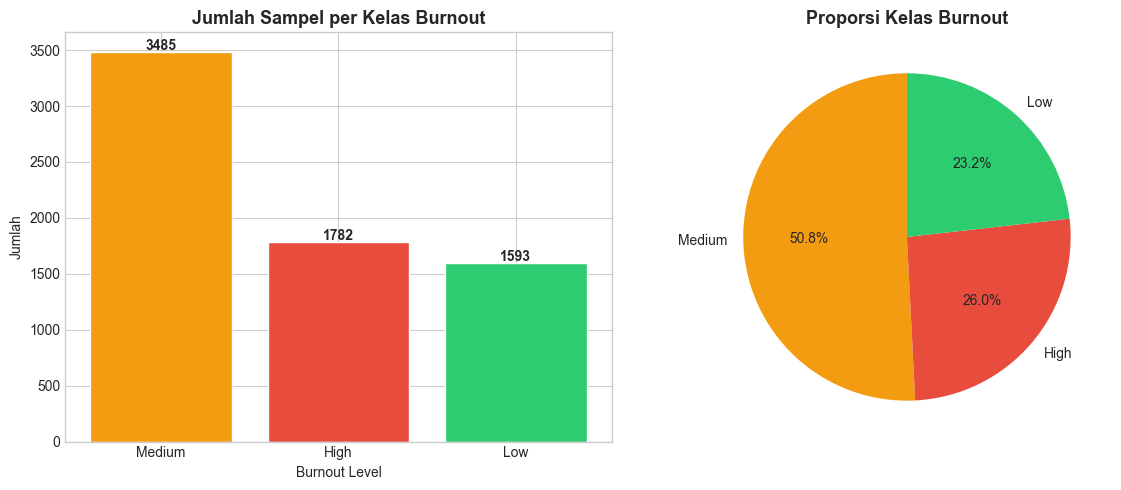

               Count  Percentage (%)
burnout_level                       
Medium          3485          50.800
High            1782          25.980
Low             1593          23.220


In [5]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
bar_colors = [colors.get(k, '#95a5a6') for k in target_counts.index]

axes[0].bar(target_counts.index, target_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Jumlah Sampel per Kelas Burnout', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Jumlah')
for i, (label, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90)
axes[1].set_title('Proporsi Kelas Burnout', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(pd.concat([target_counts, target_pct.round(2)], axis=1, keys=['Count', 'Percentage (%)']))

### 4.2 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

print(f'Total missing values: {df.isnull().sum().sum()}')
print(f'Kolom dengan missing : {len(missing_df)}')
print(missing_df)

Total missing values: 1680
Kolom dengan missing : 12
                  Count  Percentage (%)
age                 140           2.000
experience_years    140           2.000
daily_work_hours    140           2.000
sleep_hours         140           2.000
caffeine_intake     140           2.000
bugs_per_day        140           2.000
commits_per_day     140           2.000
meetings_per_day    140           2.000
screen_time         140           2.000
exercise_hours      140           2.000
stress_level        140           2.000
burnout_level       140           2.000


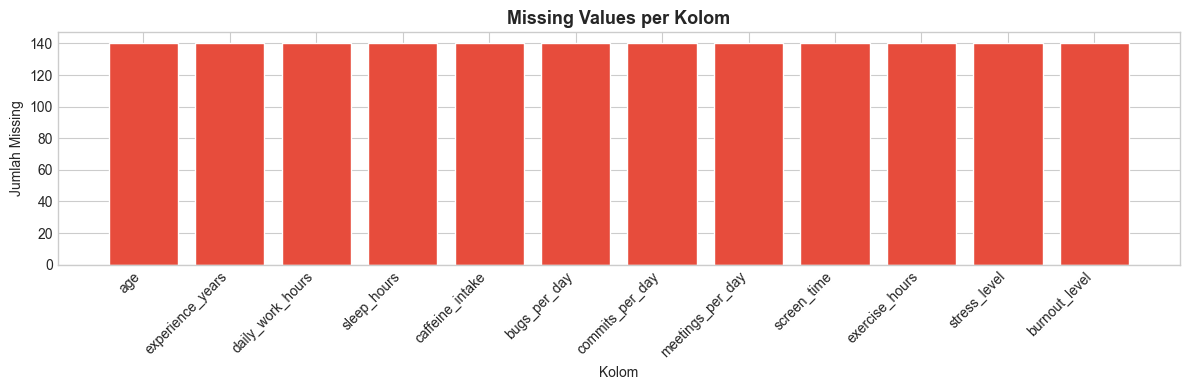

In [7]:
plt.figure(figsize=(12, 4))
missing_all = df.isnull().sum().sort_values(ascending=False)
bar_c = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_all.values]
plt.bar(missing_all.index, missing_all.values, color=bar_c, edgecolor='white')
plt.title('Missing Values per Kolom', fontsize=13, fontweight='bold')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Distribusi Seluruh Fitur Numerik

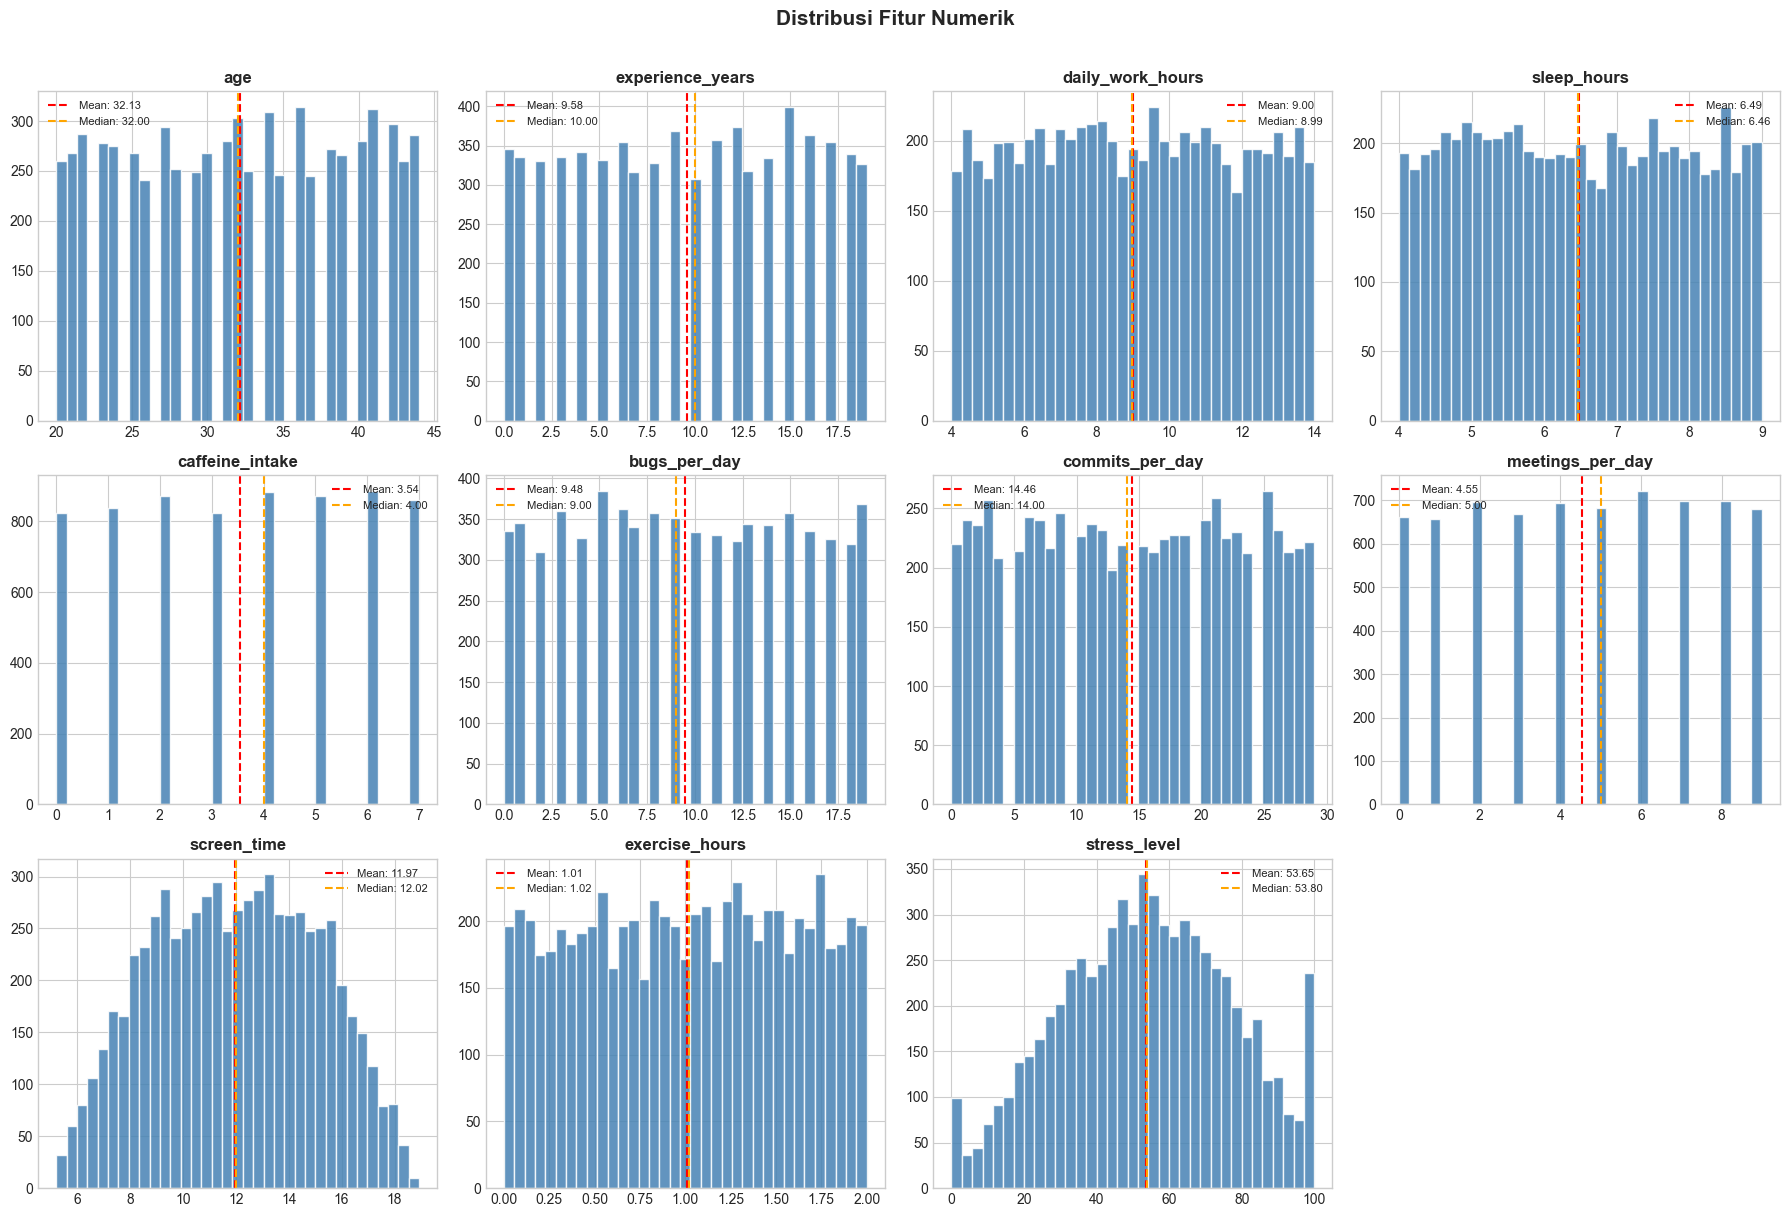

In [8]:
numerical_cols = df.select_dtypes(include='float64').columns.tolist()
feature_cols = [c for c in numerical_cols if c != TARGET]

n_cols = 4
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', label=f'Median: {data.median():.2f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Deteksi Outlier dengan Boxplot

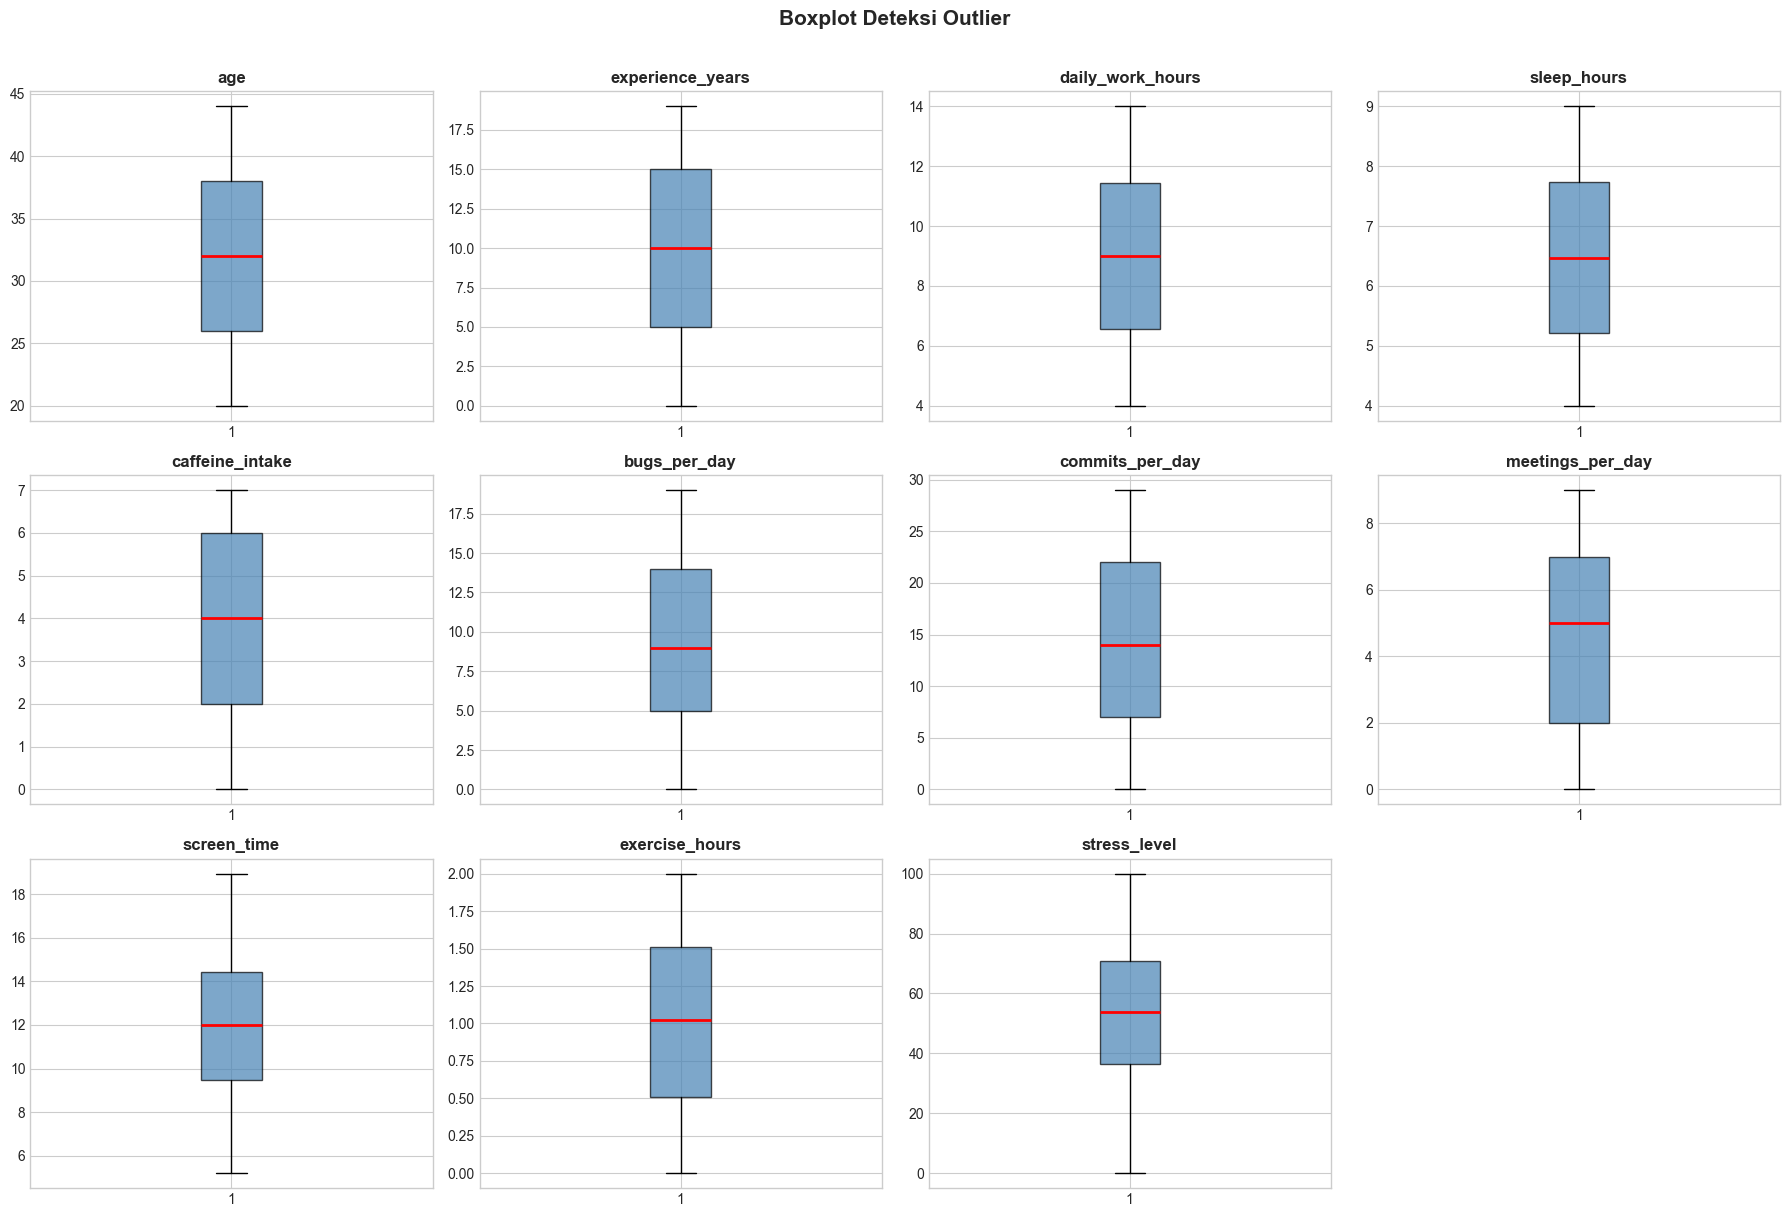

Jumlah Outlier per Kolom (IQR Method):
  age                      : 0 outlier
  experience_years         : 0 outlier
  daily_work_hours         : 0 outlier
  sleep_hours              : 0 outlier
  caffeine_intake          : 0 outlier
  bugs_per_day             : 0 outlier
  commits_per_day          : 0 outlier
  meetings_per_day         : 0 outlier
  screen_time              : 0 outlier
  exercise_hours           : 0 outlier
  stress_level             : 0 outlier


In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Deteksi Outlier', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Jumlah Outlier per Kolom (IQR Method):')
for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:<25}: {n} outlier')

### 4.5 Correlation Matrix

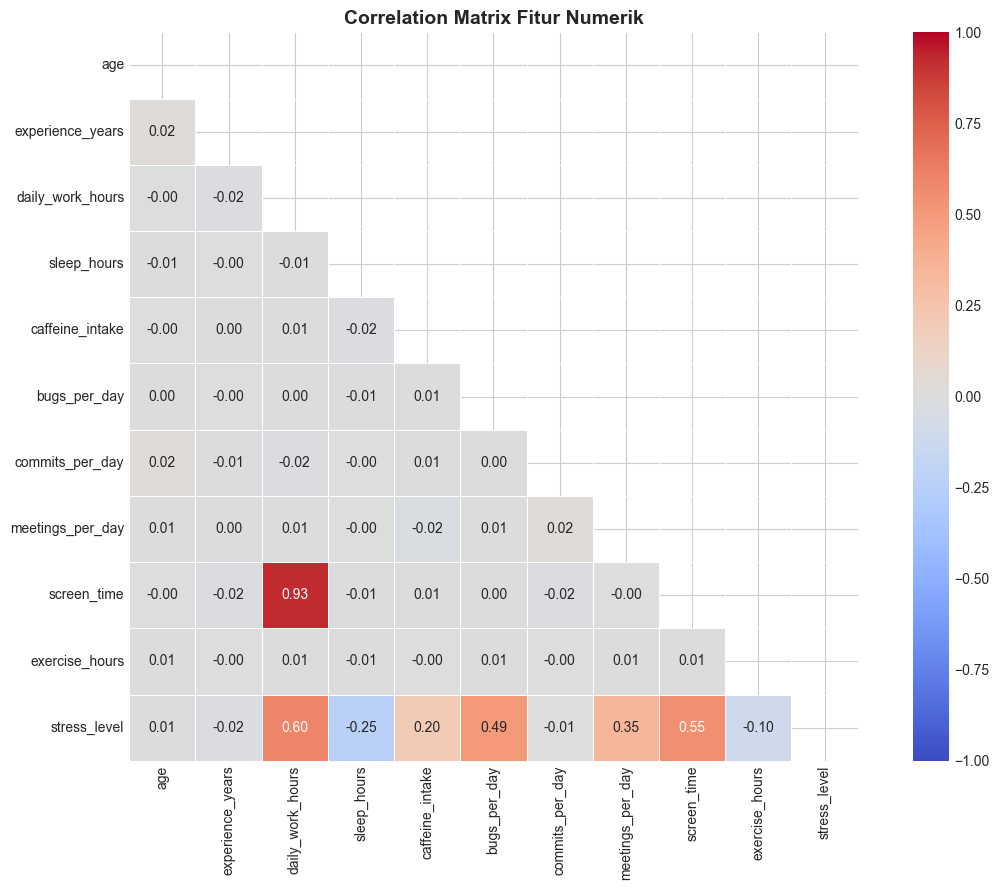

In [10]:
corr = df[feature_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Hubungan Fitur Numerik terhadap Target (`burnout_level`)

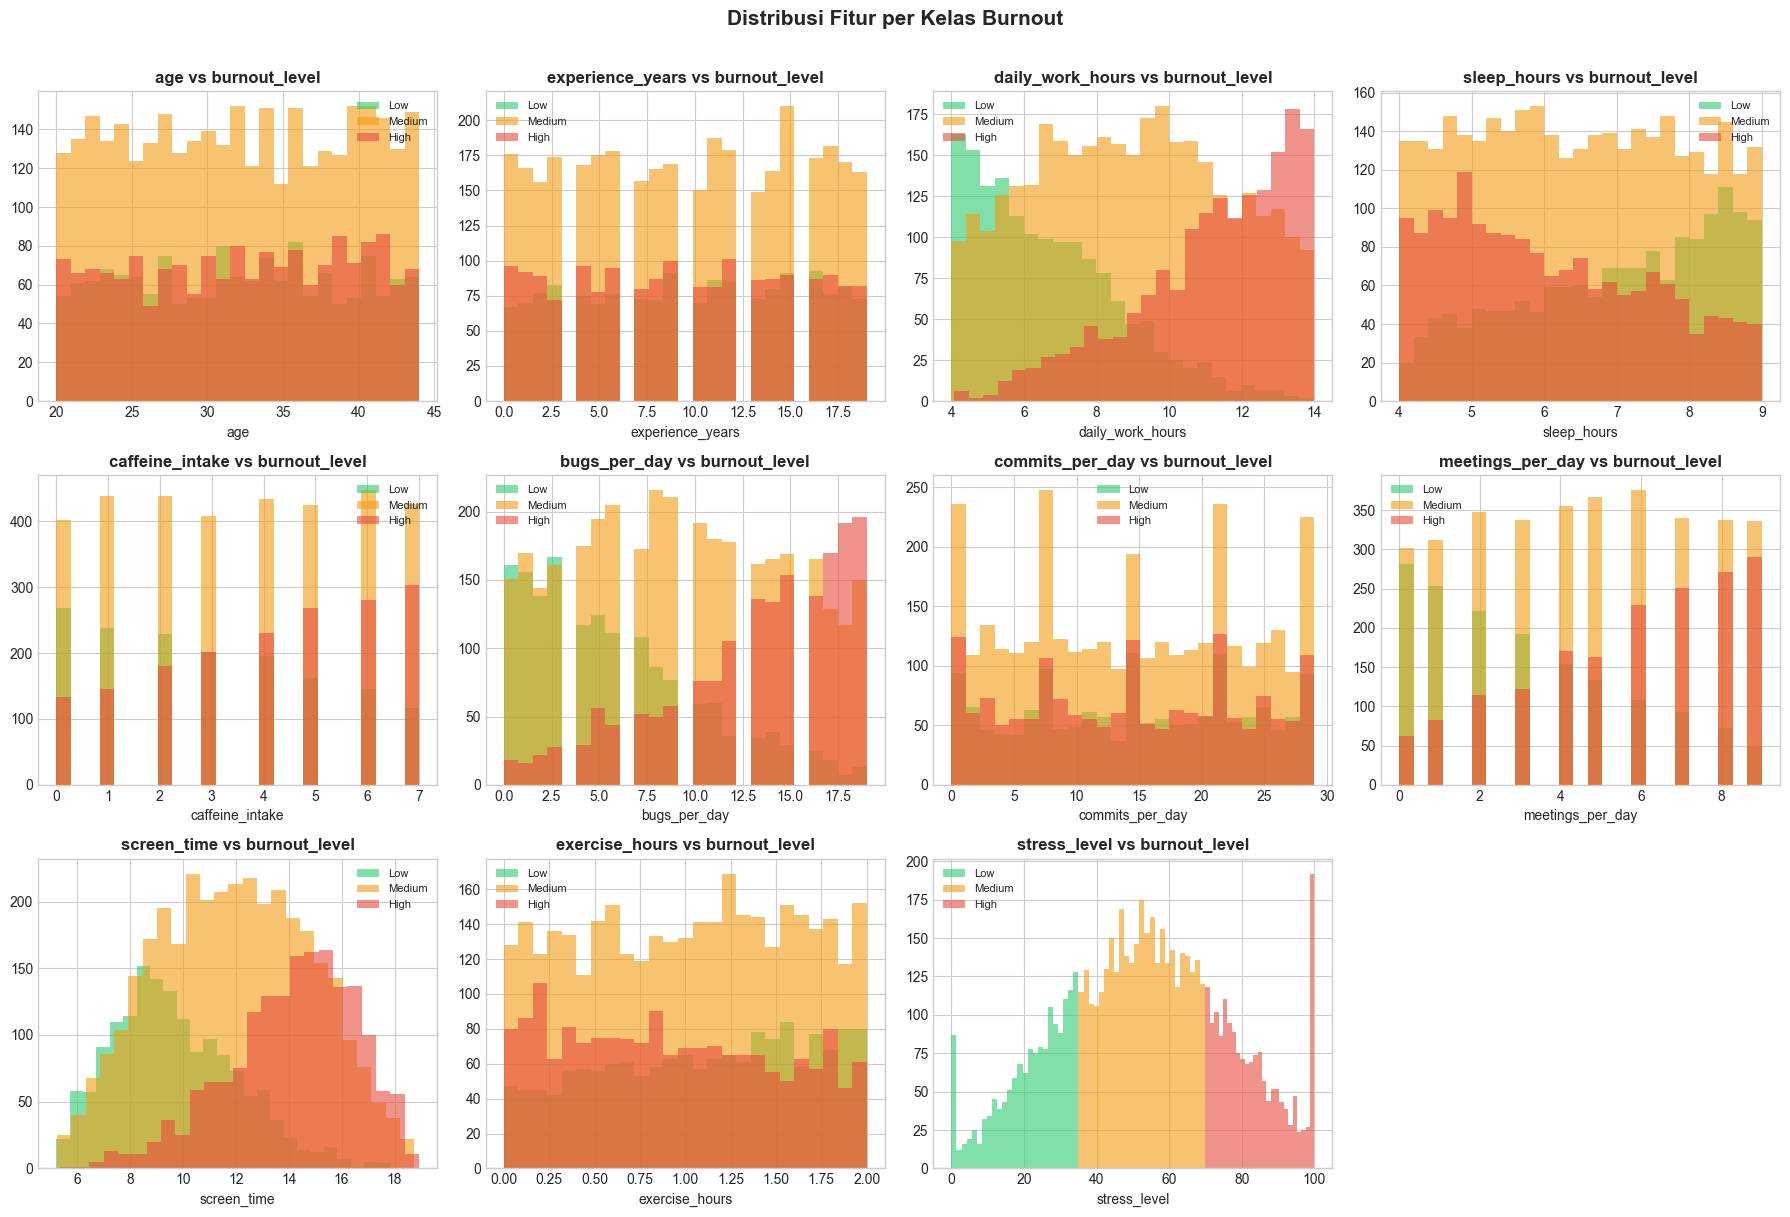

In [11]:
df_eda = df.dropna(subset=[TARGET])
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for level in order:
        subset = df_eda[df_eda[TARGET] == level][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.6, label=level, color=palette[level])
    axes[i].set_title(f'{col} vs burnout_level', fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur per Kelas Burnout', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

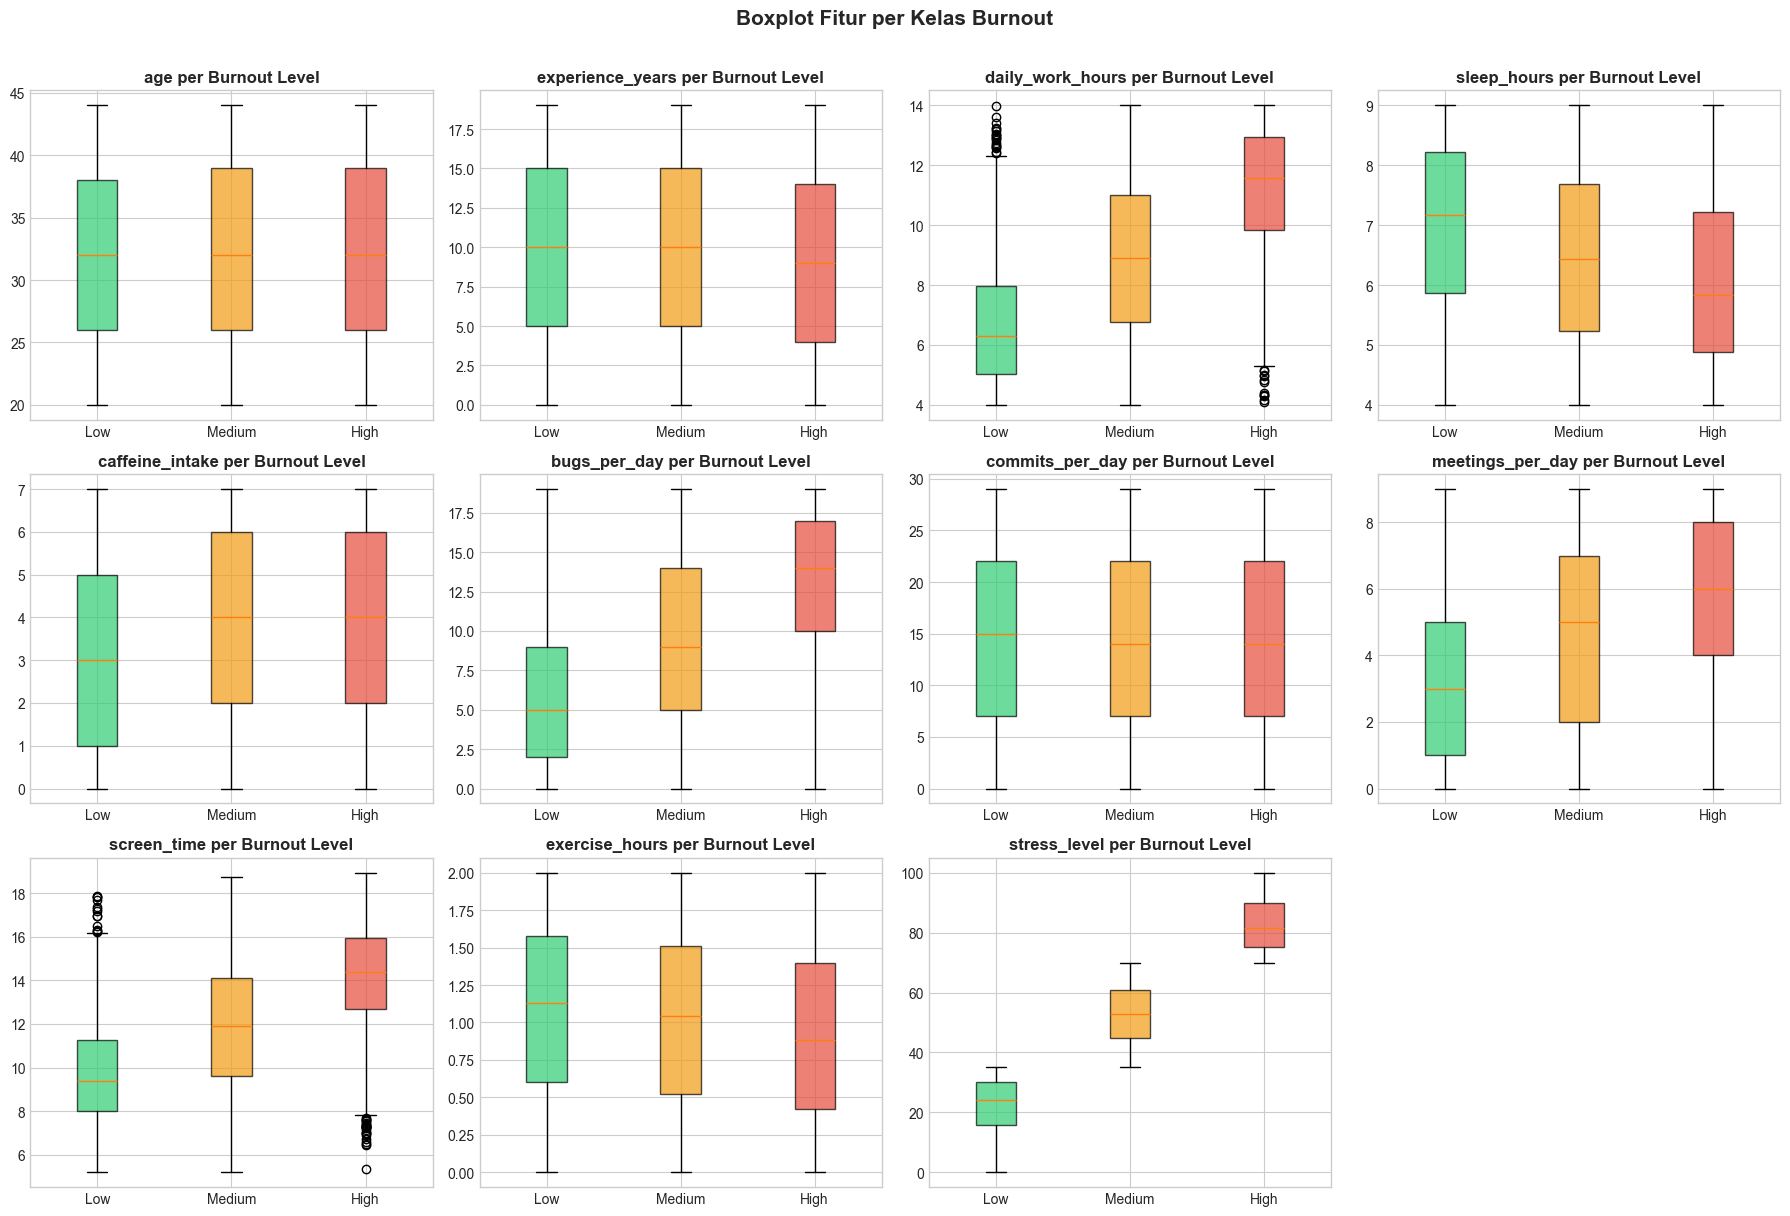

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data_by_class = [df_eda[df_eda[TARGET] == level][col].dropna().values for level in order]
    bp = axes[i].boxplot(data_by_class, labels=order, patch_artist=True)
    for patch, level in zip(bp['boxes'], order):
        patch.set_facecolor(palette[level])
        patch.set_alpha(0.7)
    axes[i].set_title(f'{col} per Burnout Level', fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Fitur per Kelas Burnout', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.7 Duplicate Check

In [13]:
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup}')

Jumlah baris duplikat: 0


**Insight EDA:**
- Terdapat **140 missing values** di setiap kolom (sekitar 2% dari total data), pola missing yang seragam mengindikasikan missing at random.
- Tidak ada data duplikat.
- Tidak ada outlier ekstrem berdasarkan metode IQR — data berada dalam rentang yang wajar.
- `stress_level` memiliki korelasi positif kuat terhadap kelas `burnout_level`.
- `sleep_hours` dan `exercise_hours` cenderung berkorelasi negatif dengan burnout tinggi.
- Distribusi target sedikit tidak seimbang: Medium dominan, namun masih dapat ditangani.

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Handling missing values (median imputation untuk fitur, mode untuk target)
2. Encoding target variable (`LabelEncoder`)
3. Feature scaling (`StandardScaler`)
4. Train-test split (80:20, stratified)
5. Simpan hasil preprocessing

### 5.1 Handling Missing Values

In [14]:
df_clean = df.copy()

for col in feature_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean[TARGET] = df_clean[TARGET].fillna(df_clean[TARGET].mode()[0])

print(f'Missing setelah handling: {df_clean.isnull().sum().sum()}')
print(f'Shape: {df_clean.shape}')

Missing setelah handling: 0
Shape: (7000, 12)


### 5.2 Encoding Target Variable

In [15]:
label_encoder = LabelEncoder()
label_encoder.fit(['Low', 'Medium', 'High'])

df_clean[TARGET] = label_encoder.transform(df_clean[TARGET])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f'Label mapping: {label_mapping}')
print(f'Distribusi target setelah encoding:\n{df_clean[TARGET].value_counts().sort_index()}')

Label mapping: {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Medium'): np.int64(2)}
Distribusi target setelah encoding:
burnout_level
0    1782
1    1593
2    3625
Name: count, dtype: int64


### 5.3 Feature Scaling

In [16]:
X = df_clean[feature_cols].copy()
y = df_clean[TARGET].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'X shape : {X_scaled.shape}')
print(f'y shape : {y.shape}')
X_scaled.describe()

X shape : (7000, 11)
y shape : (7000,)


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000
mean,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.694,-1.681,-1.764,-1.737,-1.570,-1.664,-1.684,-1.610,-2.211,-1.765,-2.312
25%,-0.856,-0.805,-0.844,-0.863,-0.685,-0.786,-0.868,-0.903,-0.803,-0.855,-0.718
50%,-0.018,0.072,-0.004,-0.018,0.199,-0.083,-0.052,0.158,0.014,0.021,0.006
75%,0.821,0.949,0.836,0.856,0.641,0.795,0.880,0.865,0.780,0.845,0.723
max,1.659,1.650,1.764,1.758,1.526,1.673,1.695,1.572,2.273,1.738,1.997


### 5.4 Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts().sort_index()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts().sort_index()}')

X_train : (5600, 11)
X_test  : (1400, 11)

Distribusi y_train:
burnout_level
0    1426
1    1274
2    2900
Name: count, dtype: int64

Distribusi y_test:
burnout_level
0    356
1    319
2    725
Name: count, dtype: int64


### 5.5 Simpan Hasil Preprocessing

In [18]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

train_df.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test.csv'),   index=False)

print(f'train.csv : {train_df.shape}')
print(f'test.csv  : {test_df.shape}')
print(f'\nFile tersimpan di folder: {OUTPUT_DIR}/')

train.csv : (5600, 12)
test.csv  : (1400, 12)

File tersimpan di folder: developer_burnout_preprocessing/
